# Telecom Churn Prediction Analysis

## Overview
1. Problem Statement
2. Data Source
3. Data Preprocessing
4. Exploratory Data Analysis
5. Model Selection
6. Model Evaluation
7. Business Interpretation
8. Conclusion

## 1. Problem Statement

Customer churn is a major challenge for a majority of companies, specifically for telecom companies, leading to significant revenue loss. Customer churning is defined as when a customer stops using a service or product by a company. This metric is often portray as a percentage of total customers and is a key performance indicator in evaluating the performance of a product or service. Being able to identify the customers that have a high risk of churning before they actually churn will allow companies to take action and mitigate loss. This project aims to predict which customers are at risk of leaving, identify the main factors driving churn, and provide targeted retention actions to mitigate loss. By analysing historical customer data and building an interactive dashboard, the company can proactively reduce churn and improve customer satisfaction.


In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Source

The dataset used for analysis is obtained from the UCI Machine Learning Repository. The dataset is randomly collected from an Iranian telecom company's database over a period of 12 months. A total of 3150 rows of data, each representing a customer, bear information for 13 columns. The attributes taht are in the data are as follows:

- Call Failures: Number of Call Failures
- Complains: Binary (0: No Complaints, 1: Complaint)
- Subscription Length: Total Months of Subscription
- Charge Amount: Ordinal Attribute (0: Lowest Amount, 9: High Amount)
- Seconds of Use: Total Seconds of Calls
- Frequency of Use: Total Number of Calls
- Frequency of SMS: Total Number of Text Messages
- Distinct Called Numbers: Total Number of Distinct Calls
- Age Group: Ordinal Attribute (1: Younger Age, 5: Older Age)
- Tariff Plan: Binary (1: Pay as You Go, 2: Contractual)
- Status: Binary (1: Active, 2: Non-Active)
- Churn: Binary (0: Non-Churn, 1: Churn)
- Customer Value: The Calculated Value of Customer

All features except churn is data collected within the first 9 months. Churn labels are teh state of the customer at the end of 12 months.

https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset

## 3. Data Preprocessing

In [206]:
# Load Dataset
df = pd.read_csv("data/Customer Churn.csv")

In [207]:
df.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [208]:
df.columns

Index(['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount',
       'Seconds of Use', 'Frequency of use', 'Frequency of SMS',
       'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age',
       'Customer Value', 'Churn'],
      dtype='object')

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

Features are of the correct datatype.

In [210]:
# Check for null values
df.isna().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

No null values

In [211]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(300)

In [212]:
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows.head()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


Since these are exact duplicates, they do not add additional information. Therefore, we can just drop these rows.

In [213]:
df = df.drop_duplicates()

In [214]:
# Inspect Spread of values
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000
mean,7.802456,0.080702,32.452982,0.974737,4534.243158,70.484912,73.789825,23.870526,2.835088,1.080351,1.240000,31.077193,474.990367,0.156491
std,7.326172,0.272424,8.723075,1.550618,4199.712303,57.401512,112.062397,17.193929,0.893503,0.271883,0.427158,8.861934,514.442198,0.363384
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,29.000000,0.000000,1458.750000,28.000000,7.000000,11.000000,2.000000,1.000000,1.000000,25.000000,117.527500,0.000000
50%,6.000000,0.000000,35.000000,0.000000,3041.000000,54.500000,22.000000,21.000000,3.000000,1.000000,1.000000,30.000000,232.520000,0.000000
75%,12.000000,0.000000,38.000000,2.000000,6500.000000,96.000000,88.000000,34.000000,3.000000,1.000000,1.000000,30.000000,790.080000,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


## 4. Exploratory Data Analysis

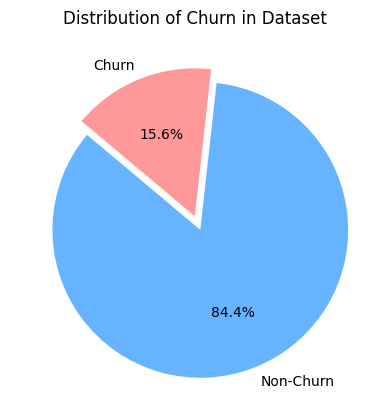

Churn counts:
Churn
0    2404
1     446
Name: count, dtype: int64


In [215]:
churn_counts = df['Churn'].value_counts()

plt.pie(churn_counts, labels=['Non-Churn', 'Churn'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'], explode=(0.1, 0))
plt.title("Distribution of Churn in Dataset")
plt.show()

print("Churn counts:")
print(churn_counts)

Dataset is quite imbalanced, with 84.4% of the customers non churning and 15.6% churning. 

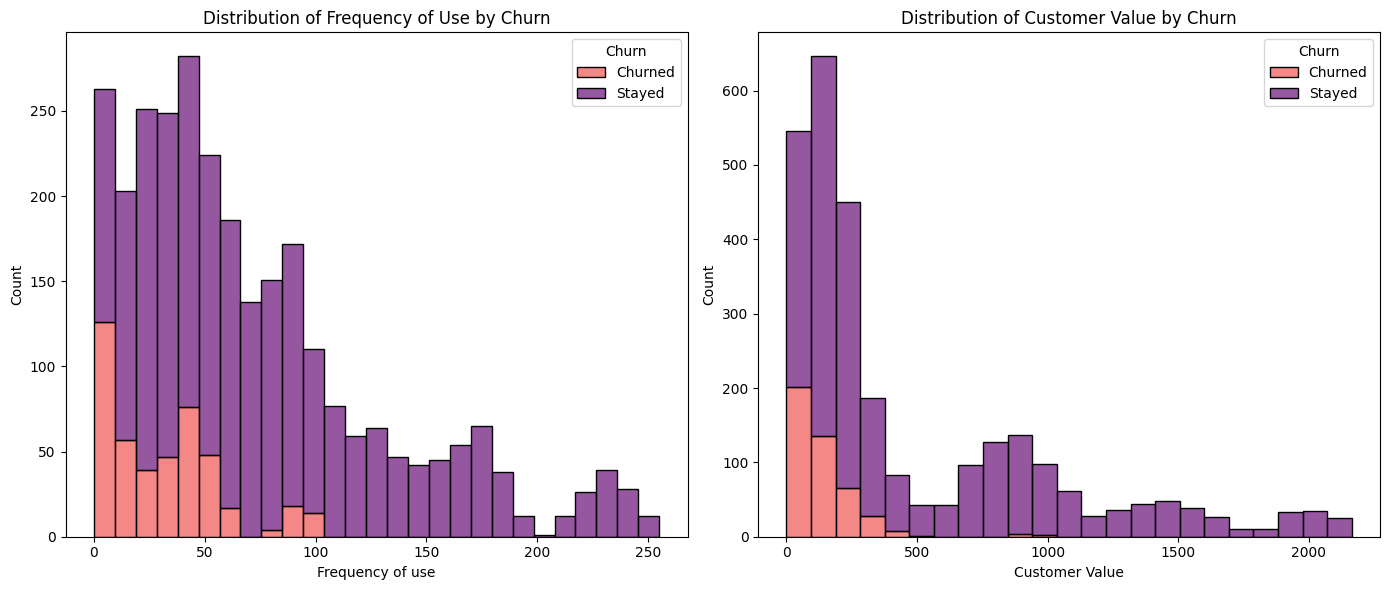

In [216]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
 
sns.histplot(data=df, x='Frequency of use', ax=ax[0], hue='Churn', palette='magma', multiple='stack')
ax[0].set_title('Distribution of Frequency of Use by Churn')
ax[0].legend(title='Churn', labels=["Churned", "Stayed"])


sns.histplot(data=df, x='Customer Value', ax=ax[1], hue='Churn', palette='magma', multiple='stack')
ax[1].set_title('Distribution of Customer Value by Churn')
ax[1].legend(title='Churn', labels=["Churned", "Stayed"])
plt.tight_layout()
plt.show()

We can see that for both plots, the values of those who stayed has a wide range whereas those who churned are skewed towards the left. This makes sense as customer are churning are less likely to use the product and will be of less customer value.

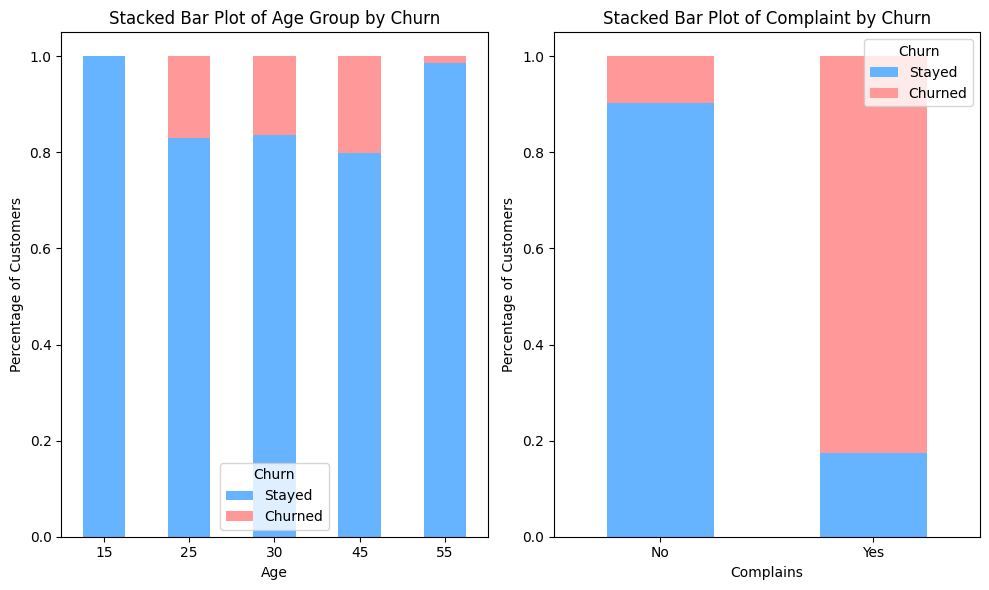

In [217]:
# Distribution of Age Groups and Churn Status
fig, ax = plt.subplots(1, 2, figsize=(10,6))

age_churn_tab = pd.crosstab(df['Age'], df['Churn'], normalize='index')
age_churn_tab.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66b3ff','#ff9999'], ax=ax[0])
ax[0].tick_params(axis='x', labelrotation=0)
ax[0].set_ylabel("Percentage of Customers")
ax[0].legend(title='Churn', labels=["Stayed", "Churned"])
ax[0].set_title('Stacked Bar Plot of Age Group by Churn')

complains_churn_tab = pd.crosstab(df['Complains'], df['Churn'], normalize='index')
complains_churn_tab.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66b3ff','#ff9999'], ax=ax[1])
ax[1].set_xticklabels(['No', 'Yes'])
ax[1].tick_params(axis='x', labelrotation=0)
ax[1].set_ylabel("Percentage of Customers")
ax[1].legend(title='Churn', labels=["Stayed", "Churned"])
ax[1].set_title('Stacked Bar Plot of Complaint by Churn')

plt.tight_layout()
plt.show()

From this plot on age group and churn, there does not seem to be a correlation between age and whether a customer will churn. The age groups in the middle have similar churn rates and the younger and older age groups have lower sample sizes. 

On the other hand, we can see that around 80% of the customers that complain tend to churn compared to the customers that do not complain churn at a 10% rate. This suggests that complains may be a driver in churning rate.

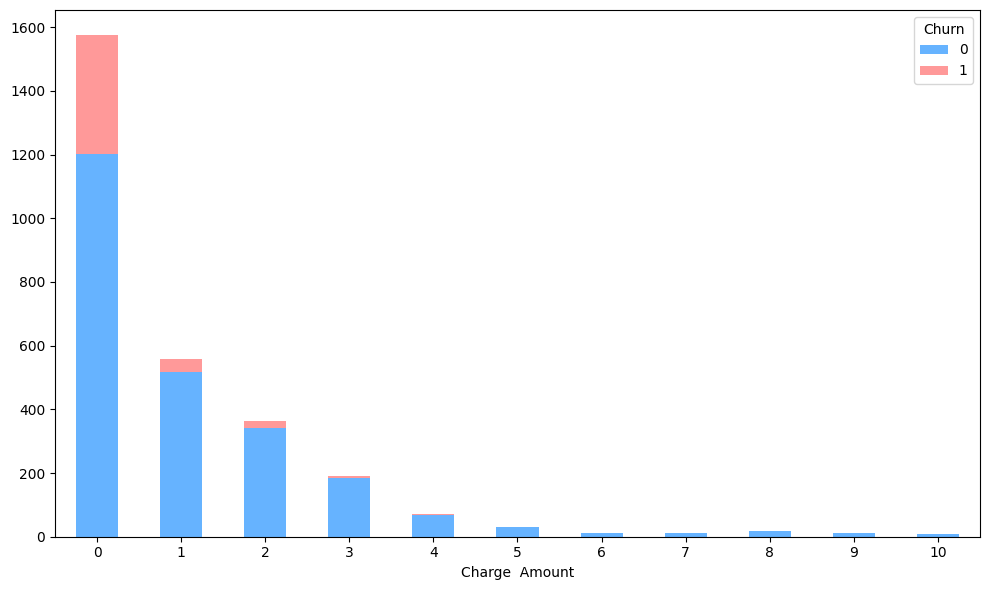

In [218]:
# Box Plot of Churn Rate and Charge Amount
# sns.barplot(data=df, x='Churn', y='Charge  Amount')
# plt.xticks([0, 1], ['Stayed', 'Churned'])
# plt.tight_layout()
# plt.show()

charge_churn = pd.crosstab(df['Charge  Amount'], df['Churn'])
charge_churn.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66b3ff','#ff9999'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

We can see that the most of the customer that churned have a low charge amount, with the churn rate decreasing as the charge amount increases. This suggests that a low charge amount may be a driving factor for customers to churn.

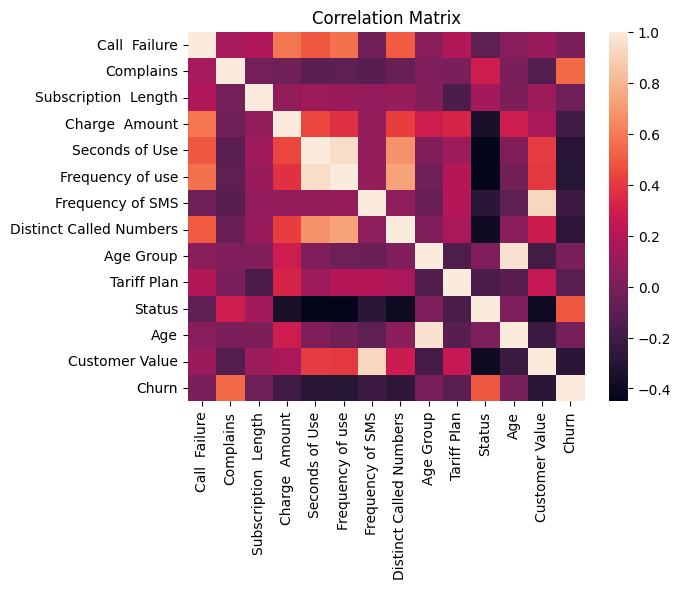

In [219]:
# Plotting correlation matrix
corr = df.corr()

sns.heatmap(corr)
plt.title("Correlation Matrix")
plt.show()

From this correlation matrix, we can that there are a few features that are correlated with each other. These are:
- Age & Age Group
- Frequency of SMS & Customer Value
- Frequency of Use & Seconds of Use

We will drop the features that have a lower absolute correlation coefficient with Churn. These are Age Group, Frequency of SMS and Seconds of Use.

In [220]:
df.to_csv('data/cleaned_churn_data.csv', index=False)

## 5. Model Selection

In [221]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

For the features, we will use the following features:
- Call Failure
- Complains
- Charge Amounts
- Frequency of Use
- Tariff Plan
- Age
- Customer Value
- Subscription Length

The metric that we will be evaluating on is the recall. We want to ensure that we are able to correctly identify all the customers that are likely to churn. Identifying customers that are likely to churn will reduce the revenue at risk and is less costly then misclassifying a customer that will not churn.

In [222]:
seed = 42

X = df[['Call  Failure', 'Complains', 'Charge  Amount', 'Frequency of use', 'Tariff Plan', 'Age', 'Customer Value', 'Subscription  Length']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

#### Baseline Model

We will first train the model using only stratified K-fold and stratify train-test split to see how well the model will perform if we do address the imbalanced distribution of the classes. We will be applying a standard scaler to each model to ensure that the continuous variables coefficients were comparable, especially for the logistic regression model.

In [223]:
results_baseline=[]

pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, random_state=seed))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=seed))
    ]),
    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', xgb.XGBClassifier(random_state=seed))
    ])
}

for name, pipe in pipelines.items():
    cv_results = cross_validate(
        pipe, X_train, y_train,
        cv=skf,
        scoring=['recall', 'precision', 'f1', 'roc_auc'],
        n_jobs=-1
    )

    results_baseline.append({
        "Model": name,
        "Avg Recall": cv_results['test_recall'].mean(),
        "Avg Precision": cv_results['test_precision'].mean(),
        "Avg F1": cv_results['test_f1'].mean()
    })

results_baseline_df = pd.DataFrame(results_baseline).sort_values(by="Avg F1", ascending=False)

In [224]:
results_baseline_df['Strategy'] = 'Baseline'
results_baseline_df

,Model,Avg Recall,Avg Precision,Avg F1,Strategy
2,XGBoost,0.775900,0.843545,0.807818,Baseline
1,Random Forest,0.716941,0.874650,0.787555,Baseline
0,Logistic Regression,0.453717,0.852916,0.592041,Baseline


We can see that the average recall for all the model is quite low ranging from 0.45 to 0.7, compared to the average precision. This indicates that the model is overfitting on the minority, which is the opposite of what we want from our model performance.

#### SMOTE
As the dataset is imbalanced, inferences and results from these analyses will be biased towards the majority class, in this case the individuals that do not churn. One of the strategies to account for an imbalanced dataset is Synthetic Minority Oversampling Technique (SMOTE). It is a method for oversampling where synthetic samples similar to current observations of the minority class are created such that the class distribution will be more even.

In [225]:
results_smote=[]

pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=seed)),
        ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=seed))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=seed)),
        ('classifier', RandomForestClassifier(random_state=seed))
    ]),
    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=seed)),
        ('classifier', xgb.XGBClassifier(random_state=seed))
    ])
}
    
for name, pipe in pipelines.items():
     
    cv_results = cross_validate(
        pipe, X_train, y_train,
        cv=skf,
        scoring=['recall', 'precision', 'f1'],
        n_jobs=-1
    )
    
    results_smote.append({
        "Model": name,
        "Avg Recall": cv_results['test_recall'].mean(),
        "Avg Precision": cv_results['test_precision'].mean(),
        "Avg F1": cv_results['test_f1'].mean()
    })

results_smote_df = pd.DataFrame(results_smote).sort_values(by="Avg F1", ascending=False)

In [226]:
results_smote_df['Strategy'] = 'SMOTE'
results_smote_df

,Model,Avg Recall,Avg Precision,Avg F1,Strategy
2,XGBoost,0.834585,0.797175,0.815214,SMOTE
1,Random Forest,0.817684,0.799720,0.808049,SMOTE
0,Logistic Regression,0.873983,0.458465,0.601192,SMOTE


The average recall is significantly better, with values around ~0.8 for all the models. This suggets that SMOTE is an effectively strategy in addressing the imbalanced nature of the dataset.

#### Weighted Model

Another strategy to address the imbalanced nature of the dataset is using a weighted model. Instead of creating new synthetic data, the model instead adjusts the weights on each class. This means that misclassifying a customer that will churn will result in a larger penalty compared to a customer that will not churn.

In [227]:
results_weighted=[]

pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(class_weight='balanced', random_state=seed))
    ]),
    "XGBoost": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', xgb.XGBClassifier(scale_pos_weight=5, random_state=seed))
    ])
}
    
for name, pipe in pipelines.items():
     
    cv_results = cross_validate(
        pipe, X_train, y_train,
        cv=skf,
        scoring=['recall', 'precision', 'f1'],
        n_jobs=-1
    )
    
    results_weighted.append({
        "Model": name,
        "Avg Recall": cv_results['test_recall'].mean(),
        "Avg Precision": cv_results['test_precision'].mean(),
        "Avg F1": cv_results['test_f1'].mean()
    })

results_weighted_df = pd.DataFrame(results_weighted).sort_values(by="Avg F1", ascending=False)

In [228]:
results_weighted_df['Strategy'] = 'Weighted'
results_weighted_df

,Model,Avg Recall,Avg Precision,Avg F1,Strategy
2,XGBoost,0.834703,0.817980,0.825783,Weighted
1,Random Forest,0.722574,0.871813,0.789841,Weighted
0,Logistic Regression,0.876721,0.460139,0.603202,Weighted


The weighted model performed quite similarly to the SMOTE model, with average recall values around ~0.8, although it achieved quite a high recall for the logistic regression model.

In [229]:
all_results = pd.concat([results_baseline_df, results_smote_df, results_weighted_df], ignore_index=True)
all_results

,Model,Avg Recall,Avg Precision,Avg F1,Strategy
0,XGBoost,0.775900,0.843545,0.807818,Baseline
1,Random Forest,0.716941,0.874650,0.787555,Baseline
2,Logistic Regression,0.453717,0.852916,0.592041,Baseline
3,XGBoost,0.834585,0.797175,0.815214,SMOTE
4,Random Forest,0.817684,0.799720,0.808049,SMOTE
5,Logistic Regression,0.873983,0.458465,0.601192,SMOTE
6,XGBoost,0.834703,0.817980,0.825783,Weighted
7,Random Forest,0.722574,0.871813,0.789841,Weighted
8,Logistic Regression,0.876721,0.460139,0.603202,Weighted


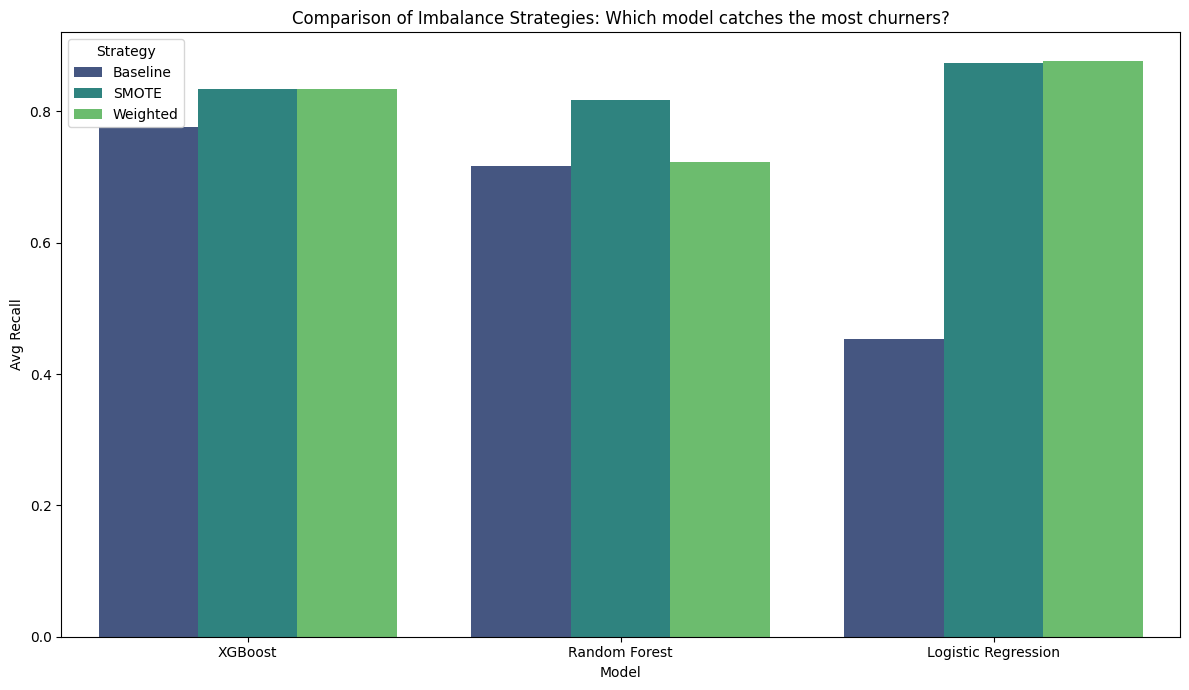

In [230]:
# Bar plot comparing average recall of different models
plt.figure(figsize=(12, 7))

sns.barplot(data=all_results, x='Model', y='Avg Recall', hue='Strategy', palette='viridis')
plt.title("Comparison of Imbalance Strategies: Which model catches the most churners?")

plt.tight_layout()
plt.show()

From this bar plot comparing the average recall obtained from each model, the model that performed the best is the logistic regression model, with an average recall of 0.87 whereas the worse is the baseline logistic regression model at around ~0.4. 

One reason that may explain why Logistic Regression was able to outperform the more complex models of XGBoost and Random Forest is that the data might have been linearly separable, which is data that Logistic Regression works well on. 

We will use this as the main model for evaluating.

## 6. Model Evaluation

We will perform hyperparameter tuning for our best model (weighted logistic regression) using RandomizedSearchCV. This method is faster and uses less computing power compared to GridSearchCV.

In [231]:
from sklearn.model_selection import RandomizedSearchCV

pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])

param_grid = {
    'lr__C': [0.01, 0.1, 1, 10],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear', 'saga'],
    'lr__class_weight': [None, 'balanced']
}


random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=skf,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('lr',
                                              LogisticRegression(class_weight='balanced',
                                                                 max_iter=1000))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'lr__C': [0.01, 0.1, 1, 10],
                                        'lr__class_weight': [None, 'balanced'],
                                        'lr__penalty': ['l1', 'l2'],
                                        'lr__solver': ['liblinear', 'saga']},
                   scoring='recall', verbose=1)

In [232]:
print(f"Best Recall Score: {random_search.best_score_}")
print(f"Best Parameters: {random_search.best_params_}")

# This is your final, "Super Model"
best_model = random_search.best_estimator_

Best Recall Score: 0.8963223787167449
Best Parameters: {'lr__solver': 'saga', 'lr__penalty': 'l2', 'lr__class_weight': 'balanced', 'lr__C': 0.01}


Hyperparameter tuning resulted in the average recall to increase from 0.87 to 0.89, which is an improvement.

#### Inference

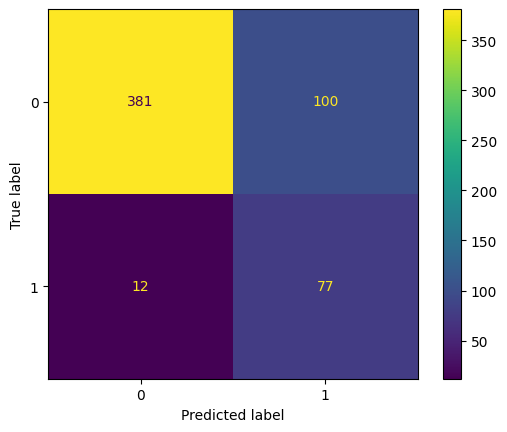

In [233]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate Predictions using our best model
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)

# Create and plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

We can see that the model performed quite similarly to the training data, with a recall of 0.87. Although the number of false positive seems quite high, this is typical for churn models as businesses prioritise correctly identifying high risk customers over misclassifying low-risk customers as the former would result in a high loss of revenue. The number of false positives will be concerning when its value is extremely high.

In [234]:
# Dump best model to be used in streamlit dashboard

import joblib
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(X_train.columns.tolist(), 'features.pkl');

In [235]:
# Add additional columns for key performance metrics
X_test['Probability of Churn'] = y_pred_prob[:, 1]
X_test['High Risk Customer'] = np.where(X_test['Probability of Churn'] > 0.75, 1, 0)
X_test['Revenue at Risk'] = X_test['Probability of Churn']*X_test['Customer Value']
X_test['Churn Prediction'] = y_pred
X_test['Churn'] = y_test
X_test.to_csv("data/X_test.csv")

#### Model Interpretation

In [236]:
# Plot coefficients of the model
features = X_train.columns
coefficients = best_model.named_steps['lr'].coef_[0]
feature_importance = pd.DataFrame({
    'feature': features,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)  # magnitude for importance
}).sort_values(by='abs_coefficient', ascending=False)

feature_importance['odds_ratio'] = np.exp(feature_importance['coefficient'])
feature_importance = feature_importance.sort_values(by='abs_coefficient', ascending=False)

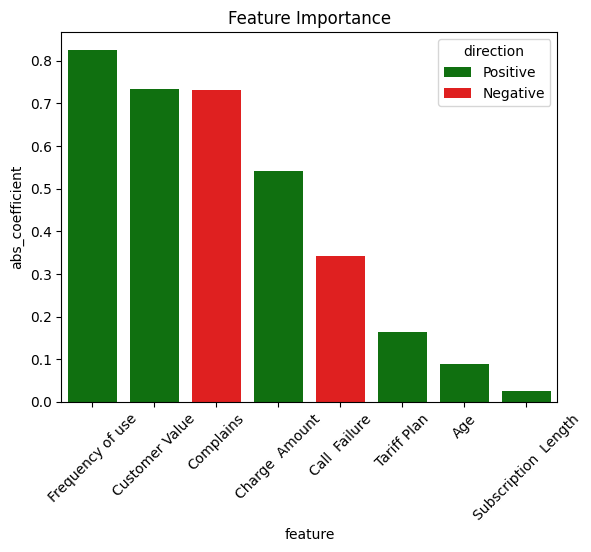

In [237]:
feature_importance['direction'] = feature_importance['coefficient'].apply(lambda x: 'Positive' if x < 0 else 'Negative')

sns.barplot(x='feature', y='abs_coefficient', data=feature_importance, hue='direction', palette={'Positive': 'green', 'Negative': 'red'})
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [238]:
feature_importance

,feature,coefficient,abs_coefficient,odds_ratio,direction
3,Frequency of use,-0.825653,0.825653,0.437949,Positive
6,Customer Value,-0.734380,0.734380,0.479803,Positive
1,Complains,0.732389,0.732389,2.080045,Negative
2,Charge Amount,-0.541971,0.541971,0.581601,Positive
0,Call Failure,0.342300,0.342300,1.408182,Negative
4,Tariff Plan,-0.163083,0.163083,0.849520,Positive
5,Age,-0.089215,0.089215,0.914649,Positive
7,Subscription Length,-0.025173,0.025173,0.975141,Positive


The logistic regression coefficients indicate that churn is driven primarily by customer behaviour and service experience rather than demographic characteristics.Features with the largest absolute standardized coefficients — frequency of use, customer value, complaints, charge amount, and call failure — have substantially greater influence on churn probability than age and tariff plan. 

This suggests that engagement and perceived service quality are more important determinants of retention than customer profile attributes.

From the coefficient signs:

- Complaints and call failures increase the odds of churn
- Frequency of use and customer value decrease the odds of churn
- Charge amount negatively relates to churn, suggesting higher-paying customers are less likely to leave

Because the features were standardized, each coefficient represents the change in log-odds of churn for a one standard deviation increase in the predictor.
Therefore, the model shows that churn is most sensitive to changes in customer experience metrics rather than demographic differences.

## 7. Business Actions

In [239]:
business_actions = pd.DataFrame({
    "Insight": [
        "Complaints strongly increase churn",
        "Call failures increase churn",
        "Low frequency of use predicts churn",
        "Low customer value predicts churn",
        "High charge amount reduces churn",
        "Age, tariff plan and subscription length are weak predictors"
    ],
    "What it means": [
        "Customers leave after negative experiences",
        "Service reliability drives dissatisfaction",
        "Customers disengage before leaving",
        "Low investment customers are less loyal",
        "High spenders are loyal but valuable",
        "Demographics don’t matter much"
    ],
    "Business Action": [
        "Trigger automatic retention workflow after complaint (call back within 24 hrs)",
        "Prioritise network troubleshooting for affected customers",
        "Send re-engagement offers or usage reminders",
        "Provide onboarding/tutorial incentives",
        "Assign VIP retention support",
        "Avoid demographic targeting campaigns"
    ],
    "Expected Impact": [
        "Reduce reactive churn",
        "Improve satisfaction & retention",
        "Prevent silent churn",
        "Increase engagement",
        "Protect revenue",
        "Save marketing budget"
    ]
})

In [240]:
display(business_actions)

,Insight,What it means,Business Action,Expected Impact
0,Complaints strongly increase churn,Customers leave after negative experiences,Trigger automatic retention workflow after com...,Reduce reactive churn
1,Call failures increase churn,Service reliability drives dissatisfaction,Prioritise network troubleshooting for affecte...,Improve satisfaction & retention
2,Low frequency of use predicts churn,Customers disengage before leaving,Send re-engagement offers or usage reminders,Prevent silent churn
3,Low customer value predicts churn,Low investment customers are less loyal,Provide onboarding/tutorial incentives,Increase engagement
4,High charge amount reduces churn,High spenders are loyal but valuable,Assign VIP retention support,Protect revenue
5,"Age, tariff plan and subscription length are w...",Demographics don’t matter much,Avoid demographic targeting campaigns,Save marketing budget


Based on the logistic regression model, we have identified the features that most strongly associate with churn. The table above translates these insights into actionable business strategies. Customers who complain or experience call failures are at highest risk, so immediate interventions are recommended. Other facators such as low engagement or low spending indicate opportunities for targeted re-engagement. This table provides a clear guide for retention actions informed by the model's predictions.

## 8. Conclusion

This project aimed to predict customer churn in a telecom company to enable targeted retention strategies. Model intepretation shows that churn is primarily driven by customer behaviour and service experience: complaints and call failures substantially increase risk of churn, while higher engagement, customer value and charge amounts reduce it. These insights inform actionable business strategies, including immediate support for complaining customers, addressing technical issues, and engage low-usage customers with incentives. By implementing these strategies, the company can proactively reduce churn and protect revenue while focusing resources on the most at-risk customers.